<a href="https://colab.research.google.com/github/youngsuchoi0930/Remote_git/blob/master/practices/practice-from_scratch_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (실습) 통계 기초

**참고**

[통계 기초](https://codingalzi.github.io/datapy/from_scratch_2.html)에
정의된 다음 함수들을 활용할 수 있다.

- mean
- median
- quantile
- mode
- data_range
- iqr
- var
- std
- cov
- corrcoef

**필수 모듈**

`matplotlib.pyplot`은 막대그래프, 히스토그램, 산점도 등 데이터를 그래프로 시각화할 때 필요한
다양한 함수를 제공하는 모듈이다.

In [31]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.1 MB/s eta 0:00:00


In [1]:
import matplotlib.pyplot as plt

# 그래프 설정
plt.rc('figure', figsize=(10, 6))  # 그래프 크기 지정

In [36]:
import platform
import matplotlib as mpl

# 윈도우 설정
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/NGULIM.TTF"
    font = mpl.font_manager.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font)
# 우분투/구글 코랩 설정
elif platform.system() == 'Linux':
    # 우분투/구글코랩의 경우 아래 명령문이 최소 한번 실행되어야 함
    !sudo apt-get install -y fonts-nanum*
    !fc-cache -fv

    font = "NanumBarunGothic"
    if not any(map(lambda ft: ft.name == font, mpl.font_manager.fontManager.ttflist)):
        mpl.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf")
    plt.rc("font", family=font)
    plt.rc("axes", unicode_minus=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 

In [ ]:
!pwd

## 데이터 준비

영산강에 설치된 승천보에서 측정한 두 개의 데이터셋이다.

- `chl_a`: 녹조 발생의 주요 요인인 클로로필-A의 수치 100개
- `flow`: 보에서 방출되는 시간당 방류량 수치 100개

두 데이터셋의 인덱스는 수질(water quality)을 가리키며,
높은 숫자일 수록 수질은 나쁘다.

In [46]:
# 클로로필-A 수치 100개

chl_a = [51, 51, 53, 53, 54, 55, 57, 57, 59, 60,
         61, 62, 63, 64, 65, 66, 67, 67, 67, 69,
         70, 71, 71, 72, 73, 75, 75, 76, 77, 79,
         81, 81, 83, 83, 85, 86, 87, 88, 88, 88,
         89, 89, 90, 91, 92, 95, 96, 96, 97, 98,
         98, 98, 99, 101, 101, 102, 102, 103, 104, 104,
         104, 104, 105, 106, 107, 108, 110, 111, 111, 112,
         112, 112, 113, 114, 114, 116, 116, 116, 117, 118,
         118, 118, 118, 119, 120, 120, 121, 122, 125, 120,
         121, 121, 121, 122, 122, 122, 122, 124, 125, 124]

In [4]:
# 시간당 방류량 수치 100개

flow = [25, 25, 24, 24, 22, 22, 21, 21, 20, 20,
        19, 19, 19, 18, 18, 18, 17, 17, 17, 16,
        16, 16, 17, 16, 17, 17, 16, 16, 16, 16,
        16, 16, 16, 16, 16, 15, 15, 15, 15, 15,
        15, 14, 15, 14, 14, 13, 13, 13, 13, 13,
        13, 13, 13, 13, 13, 13, 12, 12, 12, 12,
        12, 12, 52, 11, 11, 11, 11, 11, 12, 12,
        12, 12, 12, 11, 12, 12, 12, 11, 11, 11,
        11, 11, 11, 11, 11, 11, 11, 11, 11, 10,
        9, 9, 9, 9, 9, 9, 9, 49, 9, 9]

**문제**

각각의 데이터셋 크기가 100임을 확인하라.

힌트: `len()` 함수

In [6]:
print("클로프로필")
print(len(chl_a))
print("시간당 방류배치")
print(len(flow))

클로프로필
100
시간당 방류배치
100


**문제**

가장 높은 클로로필-A의 수치는 얼마인가?

In [7]:
print(max(chl_a))

125


**문제**

가장 낮은 시간당 방류량 수치는 얼마인가?

In [8]:
print(min(flow))

9


## 데이터 살펴보기

**문제**

클로로필-A 데이터에 포함된 값들의 빈도를 막대그래프로 그려라.

힌트: `from collections import Counter`

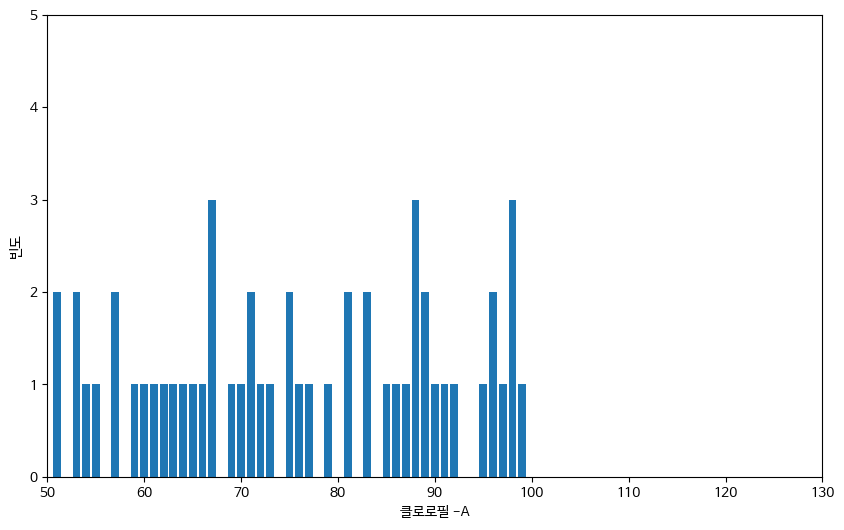

In [38]:
from collections import Counter

chl_a_counts = Counter(chl_a)

xs = range(100)
ys = [chl_a_counts[x] for x in xs]


plt.bar(xs,ys)

plt.axis([50,130,0,5])
plt.xlabel("클로로필 -A")
plt.ylabel("빈도")
plt.show()



In [13]:
chl_a_counts

Counter({51: 2,
         53: 2,
         54: 1,
         55: 1,
         57: 2,
         59: 1,
         60: 1,
         61: 1,
         62: 1,
         63: 1,
         64: 1,
         65: 1,
         66: 1,
         67: 3,
         69: 1,
         70: 1,
         71: 2,
         72: 1,
         73: 1,
         75: 2,
         76: 1,
         77: 1,
         79: 1,
         81: 2,
         83: 2,
         85: 1,
         86: 1,
         87: 1,
         88: 3,
         89: 2,
         90: 1,
         91: 1,
         92: 1,
         95: 1,
         96: 2,
         97: 1,
         98: 3,
         99: 1,
         101: 2,
         102: 2,
         103: 1,
         104: 4,
         105: 1,
         106: 1,
         107: 1,
         108: 1,
         110: 1,
         111: 2,
         112: 3,
         113: 1,
         114: 2,
         116: 3,
         117: 1,
         118: 4,
         119: 1,
         120: 3,
         121: 4,
         122: 5,
         125: 2,
         124: 2})

## 중심 경향성과 평균

**문제**

방류량의 평균값을 계산하라.

In [20]:
def mean(x):

  return sum(x) / len(x)
mean(flow)

14.93

**문제**

In [39]:
import numpy as np
np.mean(flow)

np.float64(14.93)

방류량의 중앙값을 계산하라.

In [21]:
def midium(x):

  if len(x) % 2 == 1:
    sort_x= sorted(x)
    midium_x = len(x) // 2
    midium_value = sort_x[midium_x]
    return midium_value

  else:
    sort_x = sorted(x)
    high_midipoint = len(x)//2
    midium_value_2 = (sort_x[high_midipoint -1] + sort_x[high_midipoint]) /2
    return midium_value_2


midium(flow)

13.0

In [42]:
np.median(flow)

np.float64(13.0)

**문제**

방류량의 최빈값을 계산하라.

In [22]:
def mode(x):
  counts = Counter(x)
  max_count = max(counts.values())

  return {x_i for x_i, count in counts.items() if count == max_count}
mode(flow)

{11}

In [44]:
import pandas as pd
pd.Series(flow).mode()

,0
0,11


**문제**

방류량의 제1, 제3 사분위수를 계산하라.

In [24]:
def quantile(x,p):

   sort_x = sorted(x)
   p_index = int(p*len(x))

   return sort_x[p_index]

print("1사분위수: ", quantile(flow, 0.25))
print("3사분위수: ", quantile(flow,0.75))

1사분위수:  11
3사분위수:  16


In [45]:
np.quantile(flow, [0.25, 0.75])

array([11., 16.])

## 산포도와 분산

**문제**

클로로필-A 데이터의 범위를 계산하라.

In [25]:
def data_range(x):
  return max(x) - min(x)
print(data_range(chl_a))

74


In [47]:
np.max(chl_a) - np.min(chl_a)

np.int64(74)

**문제**

클로로필-A 데이터의 분산을 계산하라.

In [49]:
def dotV(v,w):
  assert len(v) == len(w), "벡터의 길이는 동일해야 함"

  return sum(v_i * w_i for v_i, w_i in zip(v,w))

def dev_mean(xs):
  mu = mean(xs)
  return [x - mu for x in xs]

def sum_of_squares(v):
  return dotV(v,v)

In [51]:
def var(xs):

  assert len(xs) >= 2, "두 개 이상의 데이터가 필요함"

  n = len(xs)
  deviations = dev_mean(xs)
  deviations_sum = sum_of_squares(deviations)

  return deviations_sum / (n-1)
var(chl_a)

511.919595959596

In [48]:
np.var(chl_a)

np.float64(506.8004000000001)

**문제**

클로로필-A 데이터의 표준편차를 계산하라.

In [52]:
np.std(chl_a)

np.float64(22.51222778847087)

## 선형 상관관계

**문제**

클로로필-A와 시간당 방류량 사이의 공분산을 계산하고
두 데이터 사이의 상관관계를 설명하라.

In [29]:
import math

def std(xs):
  return math.sqrt(var(xs))

print(std(chl_a))

22.625640233142487


In [55]:
np.cov(chl_a, flow) # 음의 상관 관계, 자연현상임으로 인과관계 설명 ㄱㄴ

array([[511.91959596, -66.88868687],
       [-66.88868687,  40.6920202 ]])

**문제**

클로로필-A와 시간당 방류량 사이의 피어슨 상관계수를 계산하고
두 데이터 사이의 선형 상관관계를 설명하라.

In [57]:
np.corrcoef(chl_a,flow)

array([[ 1.       , -0.4634439],
       [-0.4634439,  1.       ]])

## 이상치

**산점도**

x축을 방류량, y축을 클로로필-A 수치로 지정한 다음 산점도를 그려보자.

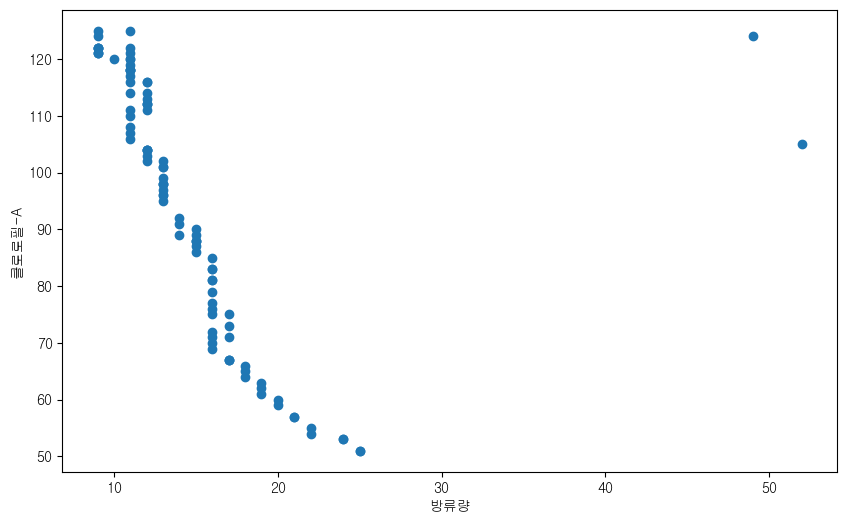

In [ ]:
plt.scatter(flow, chl_a)

# 그래프 설정
plt.xlabel("방류량")           # x축 눈금 설명
plt.ylabel("클로로필-A")       # y축 눈금 설명
plt.show()

**문제**

위 산점도에 따르면 두 개의 이상치가 존재한다.
어떤 데이터가 이상치인지 설명하라.

방류량이 50이상의 데이터 클로로필의 수치가 너무 높다

**문제**

클로로필-A 데이터와 방수량 두 데이터셋 모두에서
이상치에 해당하는 두 개의 값을 제거한다.

In [94]:
# None을 적절한 표현식으로 대체할 것.
flow_over40 = [] # 이상치
for i in range(100):
  if flow[i] >40 :
    flow_over40.append(i)
print(flow_over40)

new_flow = []
for i in range(len(chl_a)):
  if i not in flow_over40:
    # continue
    new_flow.append(flow[i])


print(len(new_flow))


[62, 97]
98


In [102]:
new_chl_a = []

for i in range(100):
  if i not in flow_over40:
    new_chl_a.append(chl_a[i])

#  if i in flow_over40:
#    continue
#  new_chl_a.append(chl_a[i])
print(len(new_chl_a))


98


In [ ]:
# None을 적절한 표현식으로 대체할 것.

new_flow = None

이상치를 제거한 두 데이터셋을 이용하여 산점도를 다시 그려라.

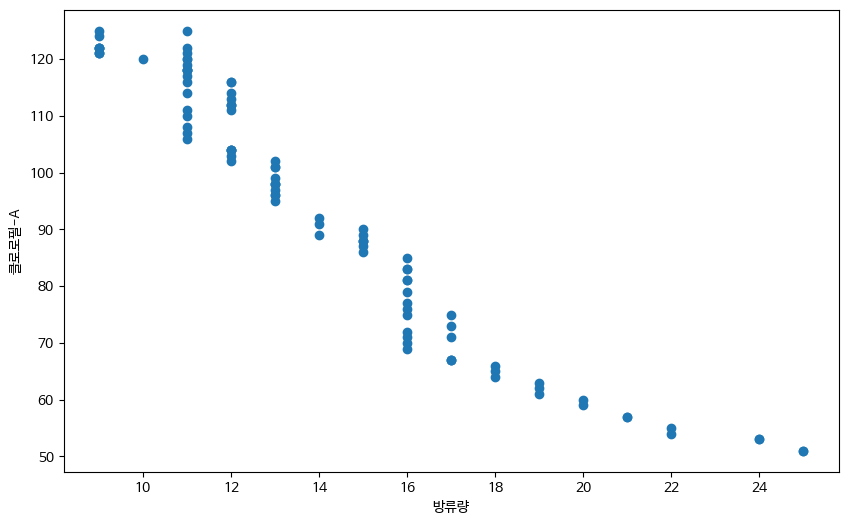

In [99]:
plt.scatter(new_flow, new_chl_a)

# 그래프 설정
plt.xlabel("방류량")           # x축 눈금 설명
plt.ylabel("클로로필-A")       # y축 눈금 설명
plt.show()

**문제**

이상치를 제거하기 이전과 이후의 데이터셋을 이용하여 아래 값들이 어떻게 달라졌는지 설명하라.

- 평균값, 중앙값, 최빈값
- 범위, 사분범위, 분산, 표준편차
- 공분산, 피어슨 상관계수

In [100]:
np.mean(chl_a), np.mean(new_chl_a)

(np.float64(93.86), np.float64(93.43877551020408))

In [103]:
np.mean(flow), np.mean(new_flow)

(np.float64(14.93), np.float64(14.204081632653061))

In [104]:
np.median(chl_a), np.median(new_chl_a)

(np.float64(98.0), np.float64(97.5))

In [105]:
np.median(flow), np.median(new_flow)

(np.float64(13.0), np.float64(13.0))